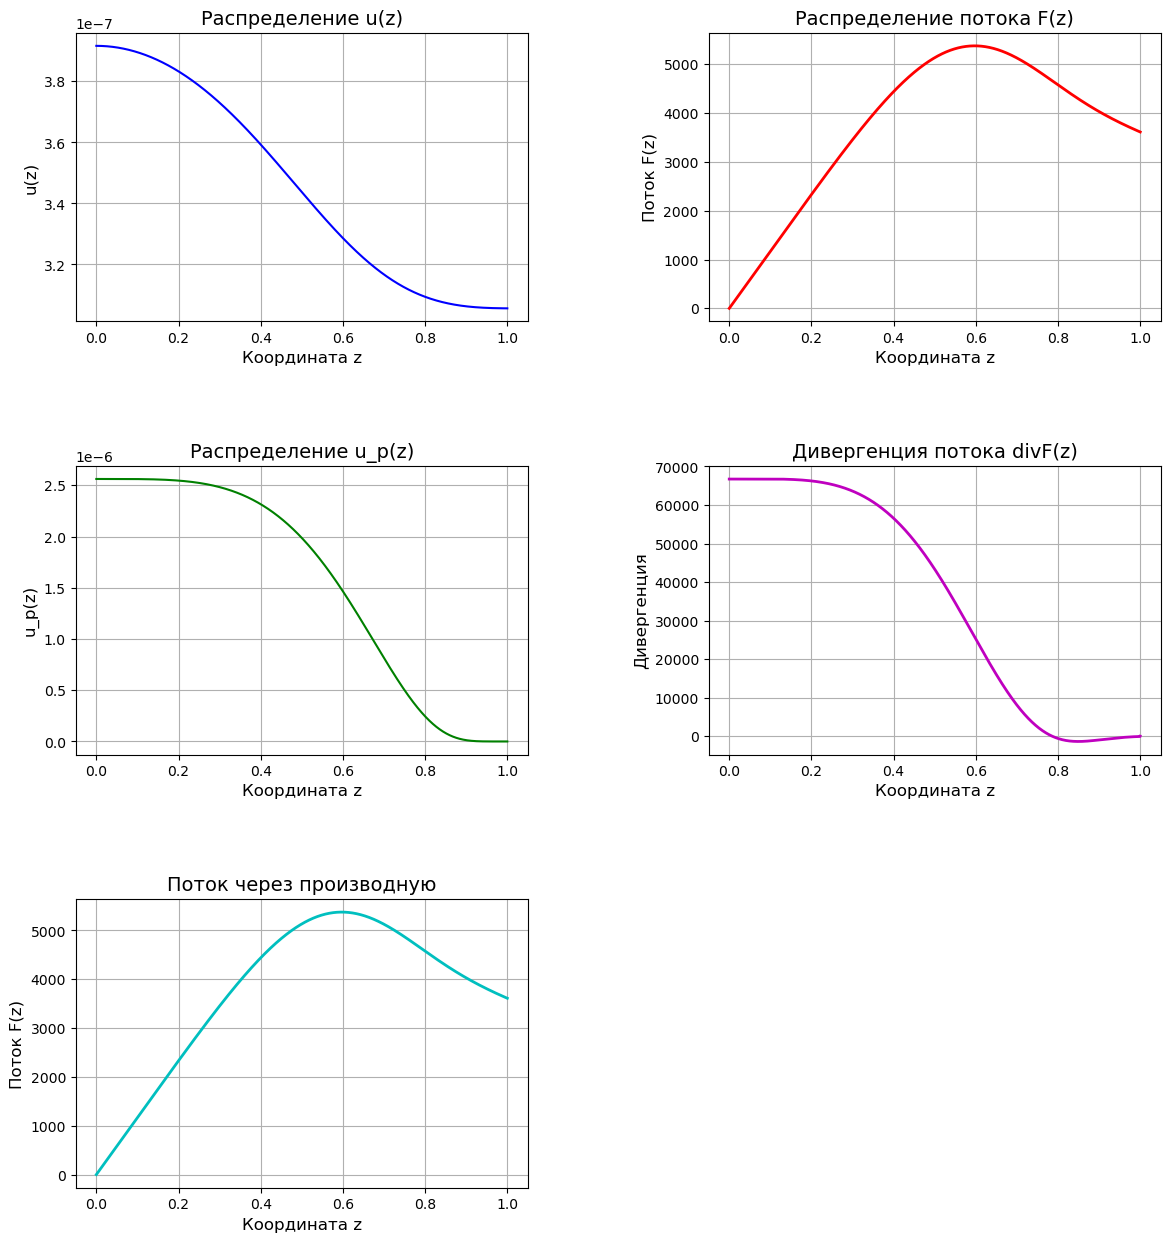

In [29]:
from numpy import e
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import numpy as np
from decimal import Decimal, getcontext

getcontext().prec = 50

# константы
k_0 = 0.008
m = 0.786
R = 0.35
T_w = 2000
T_0 = 10000
c = 3e10
p = 4
z_max = 1
z_min = 0
STEP_RK = 1e-4
EPS = 1e-6

T_values = [2000.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 10000.0]
k_values = [8.200E-03, 2.768E-02, 6.560E-02, 1.281E-01, 2.214E-01, 3.516E-01, 5.248E-01, 7.472E-01, 1.025E+00]

def quadratic_interp(x, x0, x1, x2, y0, y1, y2):
    L0 = (x - x1) * (x - x2) / ((x0 - x1) * (x0 - x2) + 1e-15)
    L1 = (x - x0) * (x - x2) / ((x1 - x0) * (x1 - x2) + 1e-15)
    L2 = (x - x0) * (x - x1) / ((x2 - x0) * (x2 - x1) + 1e-15)
    return y0 * L0 + y1 * L1 + y2 * L2

def k(r):
    temp = T(r)
    
    # Граничные случаи
    if temp <= T_values[0]:
        return k_values[0]
    if temp >= T_values[-1]:
        return k_values[-1]
    
    # Поиск ближайших трех точек
    for i in range(1, len(T_values)-1):
        if T_values[i-1] <= temp <= T_values[i+1]:
            return quadratic_interp(
                temp,
                T_values[i-1], T_values[i], T_values[i+1],
                k_values[i-1], k_values[i], k_values[i+1]
            )
    
    # Если не нашли интервал (защита от ошибок округления)
    return k_values[-1] if temp > T_values[-1] else k_values[0]
        
def T(z):
    return (T_w - T_0) * (z)**p + T_0

def u_p(z):
    return 3.084e-4 / (np.exp(47990.0 / T(z)) - 1.0)

def U_z(z, f):
    return -(3 * R * f * k(z)) / c

def F_z(z, f, u):
    if abs(z - 0) < 1e-4:
        return ((R * c) / 2) * k(z) * (u_p(z) - u)
    else:
        return R * c * k(z) * (u_p(z) - u) - (f / z)

def divF(z, u):
    return c * k(z) * (u_p(z) - u)


def k_n(z):
        return c / (3 * R * k(z))

def half_kappa(z):
    return (k_n(z + STEP_RK / 2) + k_n(z - STEP_RK / 2)) / 2

def f_n(z):
    return c * k(z) * u_p(z)

def p_n(z):
    return c * k(z)

def V_n(z):
    return ((z + STEP_RK / 2)**2 - (z - STEP_RK / 2)**2) / 2

def V_n_plus(z):
    return ((z + STEP_RK / 2)**2 - (z)**2) / 2

def V_n_minus(z):
    return ((z)**2 - (z - STEP_RK / 2)**2) / 2

# Простая аппроксимация
def approc_plus_half(func, n):
    return (func(n) + func(n + STEP_RK)) / 2

def approc_minus_half(func, n):
    return (func(n - STEP_RK) + func(n)) / 2

def A(z):
    return (z - STEP_RK / 2) * (half_kappa(z - STEP_RK / 2)) #/ (R * STEP_RK) #/ R

def C(z):
    return ((z + STEP_RK / 2) * half_kappa(z + STEP_RK / 2)) # / (R * STEP_RK) #/ R

def B(z):
    return A(z) + C(z) + p_n(z) * z * STEP_RK ** 2 * R #* V_n(z)) #* z * STEP_RK * STEP_RK * R )

def D(z):
    return f_n(z) * z * STEP_RK ** 2 * R # V_n(z) #* z * STEP_RK * STEP_RK * R )


# Краевые условия
# При х = 0
def left_boundary_condition(z0, F0, h, u_p=u_p):
    K0 = -half_kappa(z0 + h / 2) * (z0 + h / 2) + c * R * h * h / 8 * k(z0 + h / 2) * (z0 + h / 2)
    M0 = half_kappa(z0 + h / 2) * (z0 + h / 2) + c * R * h * h / 8 * k(z0 + h / 2) * (z0 + h / 2)
    P0 = c * R * h * h / 4 * k(z0 + h / 2) * u_p(z0 + h / 2) * (z0 + h / 2)

    return K0, M0, P0


# При x = N
def right_boundary_condition(z, h, u_p=u_p):
    KN = half_kappa(z - h / 2) * (z - h / 2) + m * c * z * h / 2 + c * R * h * h / 8 * k(z - h / 2) * (z - h / 2) + R * c * h * h * k(z) / 4
    MN = -half_kappa(z - h / 2) * (z - h / 2) + c * R * h * h / 8 * k(z - h / 2) * (z - h / 2)
    PN = c * R * h * h / 4 * (k(z - h / 2) * u_p(z - h / 2) * (z - h / 2) + k(z) * u_p(z))

    return KN, MN, PN


def right_hod(u_p=u_p):
    # Прямой ход
    h = STEP_RK
    K0, M0, P0 = left_boundary_condition(0, 0, STEP_RK, u_p=u_p)
    KN, MN, PN = right_boundary_condition(1, STEP_RK, u_p=u_p)  
    
    eps = [0, -K0 / M0]
    eta = [0, P0 / M0]
    x = h
    n = 1

    while x < z_max + h / 2:
        eps.append(C(x) / (B(x) - A(x) * eps[n]))
        eta.append((A(x) * eta[n] + D(x)) / (B(x) - A(x) * eps[n]))
        n += 1
        x += h

    # Обратный ход
    u = [0] * (n)
    
    u[n-1] = (PN - MN * eta[n]) / (KN + MN * eps[n]) 

    for i in range(n - 2, -1, -1):
        u[i] = eps[i + 1] * u[i + 1] + eta[i + 1]# /8.001

    return u


def center_formula(y, z, h):
    res = []
    res.append((-3 * y[0] + 4 * y[1] - y[2]) / 2 / h)

    for i in range(1, len(y) - 1):
        r = (y[i + 1] - y[i - 1]) / 2 / h
        res.append(r)

    res.append((3 * y[-1] - 4 * y[-2] + y[-3]) / 2 / h)

    return res


def F_res_deriv(u, z):
    f = [0]
    u_res = center_formula(u, z, STEP_RK)

    for i in range(1, len(z)):
        r = -c / 3 / R / k(z[i]) * u_res[i]
        f.append(r)

    return f


def F_res_integ(z, un, un1, f):
    return half_kappa(z - STEP_RK / 2) * (un - un1) / STEP_RK


# График
def draw():
    name = ['U(z)', 'F(z)']
    u_res = right_hod()
    z_res = [i for i in np.arange(0, 1 + STEP_RK, STEP_RK)]
    
    f_res = [0] * len(z_res)
    up_res = [0] * len(z_res)
    divF_ = [0] * len(z_res)

    f3_res = F_res_deriv(u_res, z_res)

    for i in range(0, len(z_res) - 1):
        up_res[i] = u_p(z_res[i])
        divF_[i] = divF(z_res[i], u_res[i])

    for i in range(1, len(z_res)):
        f_res[i] = F_res_integ(z_res[i], u_res[i - 1], u_res[i], f_res[i - 1])

    tb = PrettyTable()
    tb.add_column("Z", z_res)
    tb.add_column("F", f_res)
    tb.add_column("F deriv", f3_res)
    tb.add_column("U", u_res)
    tb.add_column("divF", divF_)

    with open('result.txt', 'w') as f:
        f.write(str(tb))

    # Настройка графиков (3 строки, 2 столбца)
    plt.figure(figsize=(14, 15))  # Увеличиваем высоту для 3 строк
    plt.subplots_adjust(hspace=0.5, wspace=0.4)  # Больше отступов

    # График 1: u(z)
    plt.subplot(3, 2, 1)
    plt.plot(z_res, u_res, 'b', label='u(z)')
    plt.xlabel('Координата z', fontsize=12)
    plt.ylabel('u(z)', fontsize=12)
    plt.title('Распределение u(z)', fontsize=14)
    plt.grid(True)
    plt.tick_params(labelsize=10)

    # График 2: u_p(z)
    plt.subplot(3, 2, 3)
    plt.plot(z_res, up_res, 'g', label='u_p(z)')
    plt.xlabel('Координата z', fontsize=12)
    plt.ylabel('u_p(z)', fontsize=12)
    plt.title('Распределение u_p(z)', fontsize=14)
    plt.grid(True)
    plt.tick_params(labelsize=10)

    # График 3: F(z)
    plt.subplot(3, 2, 2)
    plt.plot(z_res, f_res, 'r', linewidth=2)
    plt.xlabel('Координата z', fontsize=12)
    plt.ylabel('Поток F(z)', fontsize=12)
    plt.title('Распределение потока F(z)', fontsize=14)
    plt.grid(True)
    plt.tick_params(labelsize=10)

    # График 4: divF(z)
    plt.subplot(3, 2, 4)
    plt.plot(z_res, divF_, 'm', linewidth=2)
    plt.xlabel('Координата z', fontsize=12)
    plt.ylabel('Дивергенция', fontsize=12)
    plt.title('Дивергенция потока divF(z)', fontsize=14)
    plt.grid(True)
    plt.tick_params(labelsize=10)

    # График 5: F(z) через производную
    plt.subplot(3, 2, 5)
    plt.plot(z_res, f3_res, 'c', linewidth=2)
    plt.xlabel('Координата z', fontsize=12)
    plt.ylabel('Поток F(z)', fontsize=12)
    plt.title('Поток через производную', fontsize=14)
    plt.grid(True)
    plt.tick_params(labelsize=10)
    
    plt.show()

if __name__ == "__main__":
    draw()

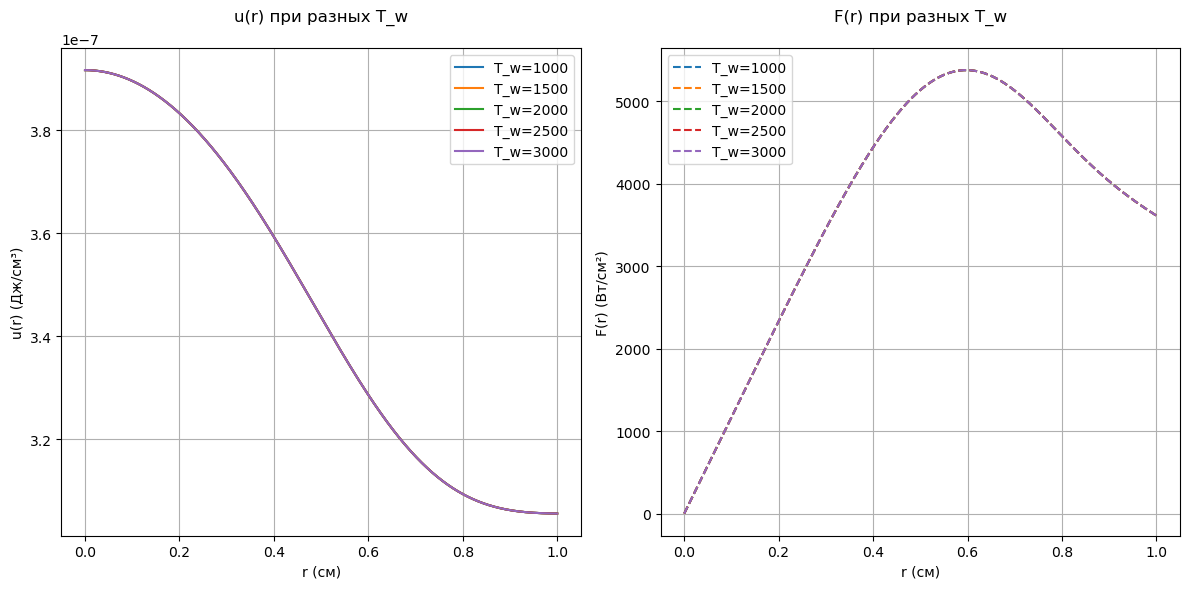

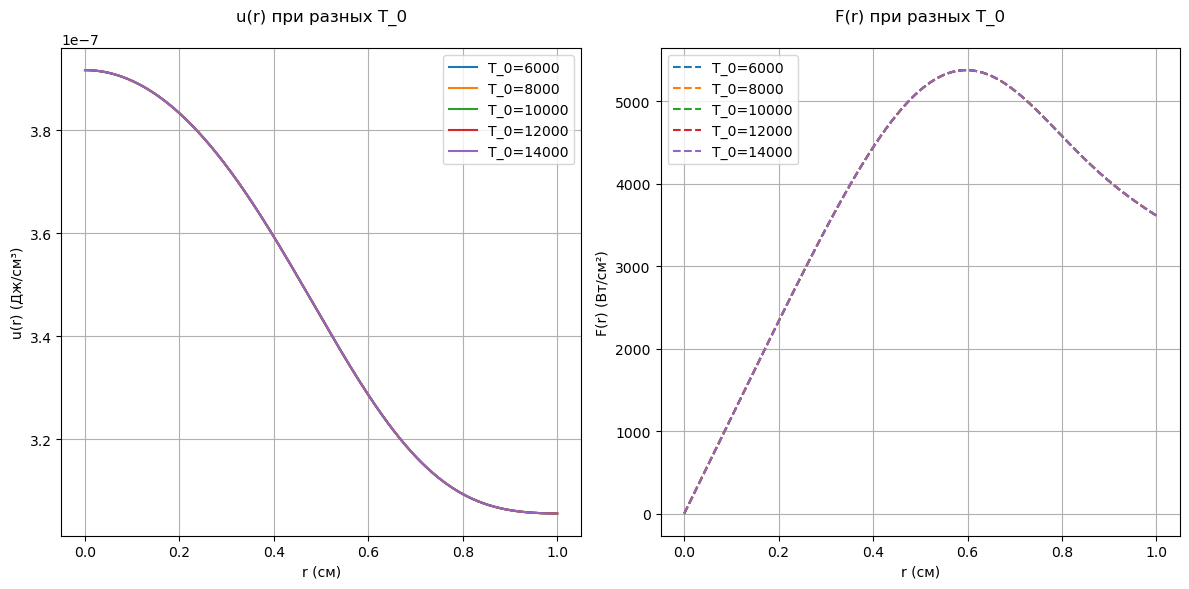

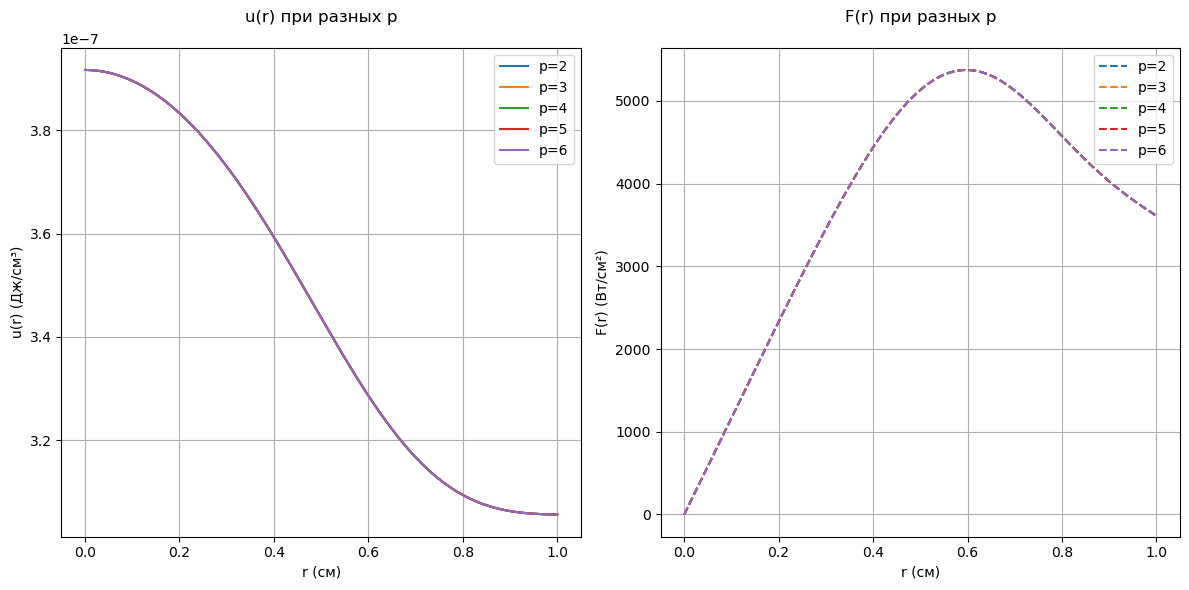

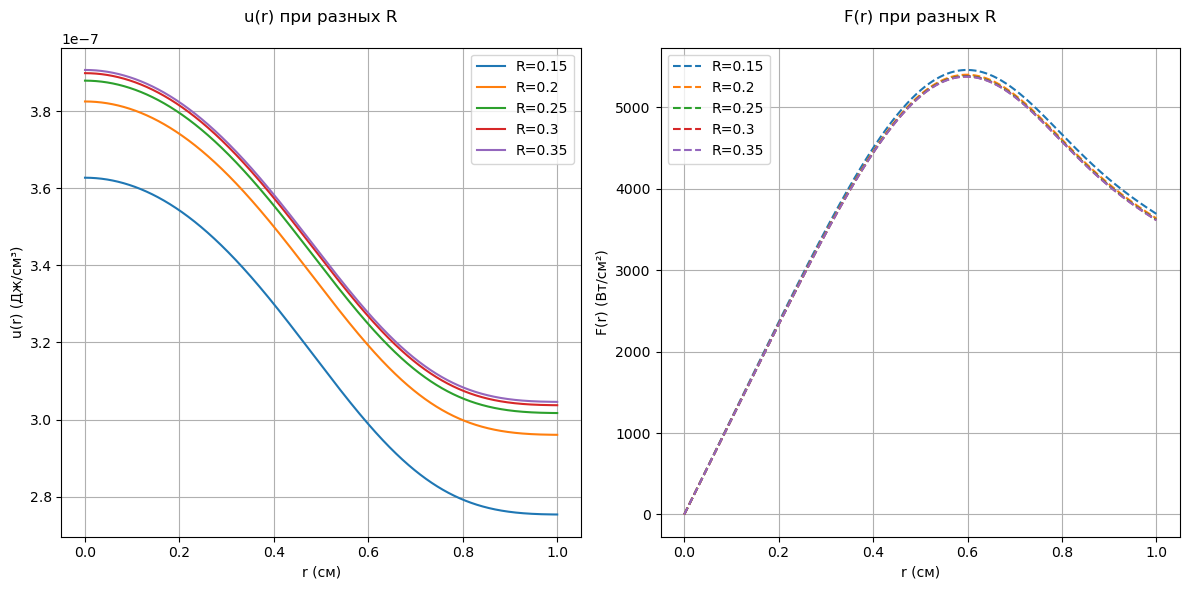

In [30]:
def investigate_parameters(u_p_func, n_steps=1000):
    u_res = right_hod(u_p=u_p_func)  # Предполагается, что right_hod и F_res_integ определены
    z_res = np.arange(0, 1 + 1/n_steps, 1/n_steps)
    f_res = [0] * len(z_res)
    for i in range(1, len(z_res)):
        f_res[i] = F_res_integ(z_res[i], u_res[i-1], u_res[i], f_res[i-1])
    return z_res, u_res, f_res

# Исследование влияния T_w
def investigate_T_w(T_w_values, n_steps=1000):
    results = []
    for T_w in T_w_values:
        def T_new(z):
            return (T_w - T_0) * (z)**p + T_0
        def u_p_new(z):
            return 3.084e-4 / (np.exp(47990.0 / T_new(z)) - 1.0)
        
        solution = investigate_parameters(u_p_new, n_steps)
        results.append((solution, T_w))
    return results

# Исследование влияния T_0
def investigate_T_0(T_0_values, n_steps=1000):
    results = []
    for T_0_val in T_0_values:
        def T_new(z):
            return (T_w - T_0_val) * (z)**p + T_0_val
        def u_p_new(z):
            return 3.084e-4 / (np.exp(47990.0 / T_new(z)) - 1.0)
        
        solution = investigate_parameters(u_p_new, n_steps)
        results.append((solution, T_0_val))
    return results

# Исследование влияния p
def investigate_p(p_values, n_steps=1000):
    results = []
    for p_val in p_values:
        def T_new(z):
            return (T_w - T_0) * (z)**p_val + T_0
        def u_p_new(z):
            return 3.084e-4 / (np.exp(47990.0 / T_new(z)) - 1.0)
        
        solution = investigate_parameters(u_p_new, n_steps)
        results.append((solution, p_val))
    return results

# Исследование влияния R (исправлены параметры вызова)
def investigate_R(R_values, n_steps=1000):
    results = []
    for R_val in R_values:
        def T_new(r):
            return (T_w - T_0) * (r / R_val)**p + T_0
        def u_p_new(z):
            return 3.084e-4 / (np.exp(47990.0 / T_new(z)) - 1.0)
        
        solution = investigate_parameters(u_p_new, n_steps)
        results.append((solution, R_val))
    return results

# Обновленная функция для построения графиков
def plot_investigation_results(results, param_name, ):
    plt.figure(figsize=(12, 6))
    
    # График u(r)
    plt.subplot(1, 2, 1)
    for solution, param_val in results:
        z_res, u_res, f_res = solution
        plt.plot(z_res, u_res, label=f'{param_name}={param_val}')
    plt.xlabel('r (см)')
    plt.ylabel('u(r) (Дж/см³)')
    plt.title(f'u(r) при разных {param_name}\n')
    plt.legend()
    plt.grid(True)
    
    # График F(r)
    plt.subplot(1, 2, 2)
    for solution, param_val in results:
        z_res, u_res, f_res = solution
        plt.plot(z_res, f_res, '--', label=f'{param_name}={param_val}')
    plt.xlabel('r (см)')
    plt.ylabel('F(r) (Вт/см²)')
    plt.title(f'F(r) при разных {param_name}\n')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Примеры вызовов функций (предполагается, что T_0, T_w, p заданы)
T_w_values = [1000, 1500, 2000, 2500, 3000]
results_T_w = investigate_T_w(T_w_values, n_steps=10000)
plot_investigation_results(results_T_w, 'T_w')

T_0_values = [6000, 8000, 10000, 12000, 14000]
results_T_0 = investigate_T_0(T_0_values, n_steps=10000)
plot_investigation_results(results_T_0, 'T_0')

p_values = [2, 3, 4, 5, 6]
results_p = investigate_p(p_values, n_steps=10000)
plot_investigation_results(results_p, 'p')

R_values = [0.15, 0.20, 0.25, 0.30, 0.35]
results_R = investigate_R(R_values, n_steps=10000)
plot_investigation_results(results_R, 'R')